In [17]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('mushroom.csv')
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


In [3]:
df.shape

(61069, 21)

In [4]:
df.isna().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,14120
cap-color,0
does-bruise-or-bleed,0
gill-attachment,9884
gill-spacing,25063
gill-color,0
stem-height,0


In [5]:
missing_df = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_df = missing_df.sort_values(
    by='Missing_Percentage',
    ascending=False
)

print(missing_df)

                      Missing_Count  Missing_Percentage
veil-type                     57892           94.797688
spore-print-color             54715           89.595376
veil-color                    53656           87.861272
stem-root                     51538           84.393064
stem-surface                  38124           62.427746
gill-spacing                  25063           41.040462
cap-surface                   14120           23.121387
gill-attachment                9884           16.184971
ring-type                      2471            4.046243
cap-color                         0            0.000000
cap-shape                         0            0.000000
cap-diameter                      0            0.000000
class                             0            0.000000
stem-height                       0            0.000000
stem-width                        0            0.000000
does-bruise-or-bleed              0            0.000000
gill-color                        0            0

In [6]:
drop_col = ['veil-type','spore-print-color','veil-color','stem-root']
df = df.drop(columns=drop_col,axis=1)

In [11]:
df.isna().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,14120
cap-color,0
does-bruise-or-bleed,0
gill-attachment,9884
gill-spacing,25063
gill-color,0
stem-height,0


In [8]:
df['stem-surface'].unique()

array(['y', nan, 's', 'k', 'i', 'h', 't', 'g', 'f'], dtype=object)

In [9]:
df['stem-surface'] = df['stem-surface'].fillna(df['stem-surface'].mode()[0])

In [10]:
df['stem-surface'].unique()

array(['y', 's', 'k', 'i', 'h', 't', 'g', 'f'], dtype=object)

In [12]:
df.columns

Index(['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-surface', 'stem-color', 'has-ring',
       'ring-type', 'habitat', 'season'],
      dtype='object')

In [13]:
nan_col = ['ring-type','gill-spacing','gill-attachment','cap-surface']
df[nan_col] = df[nan_col].fillna(df[nan_col].mode().iloc[0])

In [14]:
df.isna().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,0
cap-color,0
does-bruise-or-bleed,0
gill-attachment,0
gill-spacing,0
gill-color,0
stem-height,0


In [15]:
df.head(2)

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-surface,stem-color,has-ring,ring-type,habitat,season
0,p,15.26,x,g,o,f,e,c,w,16.95,17.09,y,w,t,g,d,w
1,p,16.60,x,g,o,f,e,c,w,17.99,18.19,y,w,t,g,d,u


In [22]:
label_col = ['class','cap-shape','cap-surface','cap-color','does-bruise-or-bleed','gill-attachment','gill-spacing','gill-color','stem-surface','stem-color','has-ring','ring-type','habitat','season']
le = LabelEncoder()
for col in label_col:
    df[col] = le.fit_transform(df[col])

In [23]:
X = df.drop(columns='class',axis=1)
y = df['class']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [25]:
y_pred = model.predict(X_test)
print("Prediction",y_pred)
print("Actual",y_test)

Prediction [0 1 0 ... 0 1 0]
Actual 11541    0
35700    1
55781    0
29303    1
46601    0
        ..
28533    1
13683    1
14595    0
50231    1
17552    0
Name: class, Length: 12214, dtype: int64


In [26]:
accuracy_score = accuracy_score(y_test,y_pred)
print("Accuracy Score",accuracy_score)
confusion_matrix = confusion_matrix(y_test,y_pred)
print("Confusion Matrix",confusion_matrix)
classification_report = classification_report(y_test,y_pred)
print("Classification Report",classification_report)

Accuracy Score 0.9999181267398067
Confusion Matrix [[5374    0]
 [   1 6839]]
Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5374
           1       1.00      1.00      1.00      6840

    accuracy                           1.00     12214
   macro avg       1.00      1.00      1.00     12214
weighted avg       1.00      1.00      1.00     12214



In [28]:
model.predict([[15.26,6,2,6,0,2,0,10,16.95,17.09,7,11,1,2,0,3]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

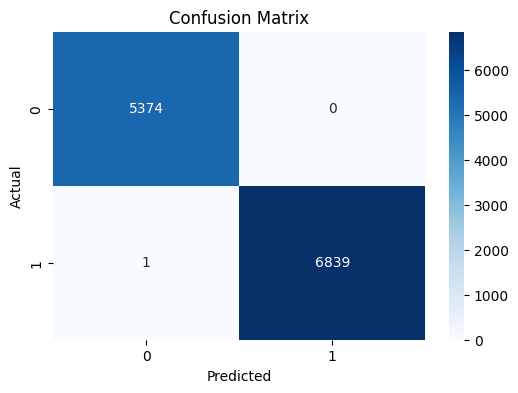

In [32]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()